In [14]:
!pip install "rfdetr[metrics]" -q

In [15]:
pip install "rfdetr[train,loggers]"

Note: you may need to restart the kernel to use updated packages.


In [ ]:


DATASET_PATH = '/kaggle/input/datasets/nomi6677/soldiers'
OUTPUT_PATH = '/kaggle/working'



In [17]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None — go to Runtime > Change runtime type > T4 GPU'}")

CUDA available: True
GPU: Tesla T4


In [72]:
from rfdetr import RFDETRSegSmall
import time

model = RFDETRSegSmall()

start_time = time.time()

model.train(
    dataset_dir=DATASET_PATH,
    epochs=25,
    batch_size=1,
    grad_accum_steps=2,
    lr=1e-4,
    output_dir=OUTPUT_PATH,
    tensorboard=True,
    precision="16-mixed",
)

print("Training time:", time.time() - start_time)

[2026-06-22 12:26:44] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-small.pt already exists with correct MD5 hash.


[2026-06-22 12:26:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-22 12:26:44] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-06-22 12:26:45] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-small.pt already exists with correct MD5 hash.


[2026-06-22 12:26:45] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-06-22 12:26:45] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-seg-small.pt' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-06-22 12:26:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-22 12:26:45] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loadi

[2026-06-22 12:26:46] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-seg-small.pt already exists with correct MD5 hash.


...

Trainable params: 33.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.4 M                                                                                               
Total estimated model params size (MB): 133.693                                                                    
Modules in train mode: 513                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-06-22 12:26:53] [INFO] rf-detr - Best EMA mAP improved to 0.0081 (epoch 0)
[2026-06-22 12:29:22] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/path/to/your/output_dir/model.pth/checkpoint_best_regular.pth (epoch 0, monitor=val/segm_mAP_50_95, value=0.304425)
[2026-06-22 12:29:22] [INFO] rf-detr - Best EMA mAP improved to 0.3047 (epoch 0)
[2026-06-22 12:31:52] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/path/to/your/output_dir/model.pth/checkpoint_best_regular.pth (epoch 1, monitor=val/segm_mAP_50_95, value=0.518669)
[2026-06-22 12:31:53] [INFO] rf-detr - Best EMA mAP improved to 0.5008 (epoch 1)
[2026-06-22 12:34:22] [INFO] rf-detr - Best EMA mAP improved to 0.5211 (epoch 2)
[2026-06-22 12:36:53] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/path/to/your/output_dir/model.pth/checkpoint_best_regular.pth (epoch 3, monitor=val/segm_mAP_50_95, value=0.5247)
[2026-06-22 12:36:53] [INFO] rf-detr - Best EMA mAP improved to 0.

`Trainer.fit` stopped: `max_epochs=25` reached.


[2026-06-22 13:29:59] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.7580, ema=0.7682)
Training time: 3793.8343555927277


[2026-06-22 14:18:21] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-22 14:18:21] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-22 14:18:21] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=100 from tensor rows 1300 ÷ ckpt_group_detr=13.
[2026-06-22 14:18:22] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


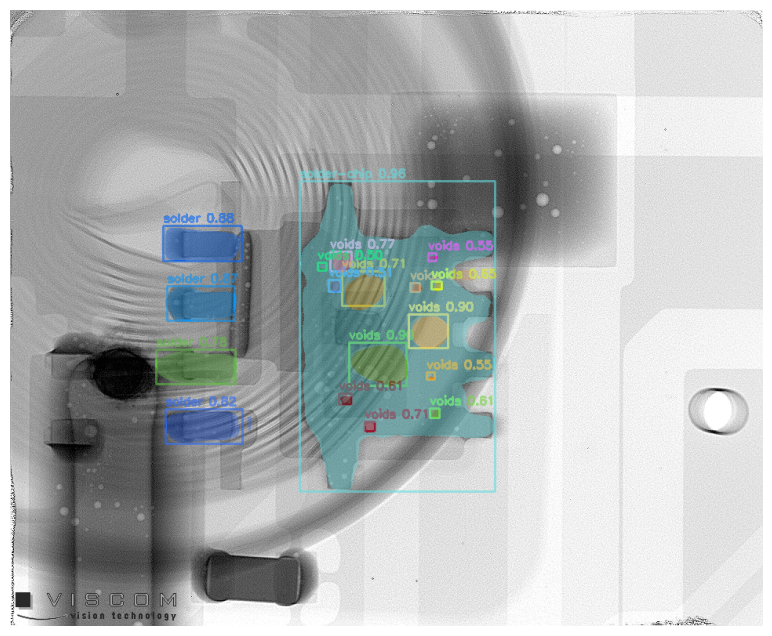

In [91]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from rfdetr import RFDETRSegSmall  

MODEL_PATH = "/kaggle/input/models/nomi6677/lll/pytorch/default/1/checkpoint_best_ema.pth"
IMAGE_PATH = "/kaggle/input/datasets/nomi6677/soldiers/valid/S6_BOTT_09Q1_(STD)_bmp.rf.9PA1d5XPXVs5ISiqU85Y.bmp"


model = RFDETRSegSmall(
    pretrain_weights=MODEL_PATH,
    patch_size=12,   # Required to match your trained checkpoint
    num_classes=10   # Matches your dataset classes
)


image = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
mask_overlay = image_rgb.copy()  # Layer where we will paint the segmented areas


results = model.predict(image_rgb)


boxes = results.xyxy
scores = results.confidence
class_names = results.data["class_name"]
masks = results.mask  # This holds the pixel-level segmented areas


np.random.seed(42)
colors = np.random.randint(0, 255, size=(len(boxes), 3), dtype=np.uint8)


for i in range(len(boxes)):
    x1, y1, x2, y2 = boxes[i].astype(int)
    score = float(scores[i])
    cls = class_names[i]
    color = [int(c) for c in colors[i]] 

 
    if masks is not None and len(masks) > i:
        instance_mask = masks[i]
        
       
        if isinstance(instance_mask, np.ndarray) and instance_mask.ndim == 2:
            mask_overlay[instance_mask > 0] = color
            
    
        elif isinstance(instance_mask, np.ndarray) and instance_mask.ndim == 3:
            cv2.fillPoly(mask_overlay, [instance_mask.astype(np.int32)], color)


    cv2.rectangle(image_rgb, (x1, y1), (x2, y2), color, 2)
    cv2.putText(
        image_rgb,
        f"{cls} {score:.2f}",
        (x1, max(0, y1 - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        color,
        2
    )


alpha = 0.4 
final_image = cv2.addWeighted(mask_overlay, alpha, image_rgb, 1 - alpha, 0)


plt.figure(figsize=(12, 8))
plt.imshow(final_image)
plt.axis("off")
plt.show()